In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import re
from google.colab import files

# 6개 파일 업로드: rfm/oes/ev × features/scores
print("6개 파일 업로드: rfm_block_features.csv, rfm_block_scores.csv,")
print("                oes_block_features.csv, oes_block_scores.csv,")
print("                ev_block_features.csv,  ev_block_scores.csv")
uploaded = files.upload()

rfm_X  = pd.read_csv('rfm_block_features.csv', index_col=0)
rfm_S  = pd.read_csv('rfm_block_scores.csv',   index_col=0)
oes_X  = pd.read_csv('oes_block_features.csv', index_col=0)
oes_S  = pd.read_csv('oes_block_scores.csv',   index_col=0)
ev_X   = pd.read_csv('ev_block_features.csv',  index_col=0)
ev_S   = pd.read_csv('ev_block_scores.csv',    index_col=0)

# 웨이퍼명에서 숫자 ID만 추출해 매칭 키로 사용
def wid(name):
    m = re.search(r'\d+', str(name)); return m.group() if m else None

for X in [rfm_X, oes_X, ev_X]:
    X['wid'] = [wid(n) for n in X.index]
for S in [rfm_S, oes_S, ev_S]:
    S['wid'] = [wid(n) for n in S.index]

common = sorted(set(rfm_X['wid']) & set(oes_X['wid']) & set(ev_X['wid']))
print(f"\nRFM: {len(rfm_X)} | OES: {len(oes_X)} | EV: {len(ev_X)} | 공통 ID: {len(common)}")

# 공통 ID 기준 정렬 & fault 라벨 일치 점검 (RFM 기준)
def align(X, S, key):
    X = X.set_index('wid').loc[common]; X = X.drop(columns=[c for c in X.columns if c=='wafer_names'], errors='ignore')
    S = S.set_index('wid').loc[common]
    return X, S

R_X, R_S = align(rfm_X, rfm_S, 'rfm')
O_X, O_S = align(oes_X, oes_S, 'oes')
E_X, E_S = align(ev_X,  ev_S,  'ev')

# fault 라벨이 세 블록에서 일치하는지 확인
labels_union = pd.concat([R_S['fault_name'], O_S['fault_name'], E_S['fault_name']], axis=1)
labels_union.columns = ['rfm','oes','ev']
mismatch = labels_union[(labels_union['rfm']!=labels_union['oes']) | (labels_union['oes']!=labels_union['ev'])]
print(f"라벨 불일치: {len(mismatch)}장")
if len(mismatch) > 0:
    print(mismatch.head())

label_all = R_S['fault_name']     # 일치 가정 — 셋이 같으면 RFM 라벨 사용
is_fault_all = (label_all != 'calibration').values
print(f"융합 데이터: {len(common)}장  (정상 {(~is_fault_all).sum()}, 이상 {is_fault_all.sum()})")

6개 파일 업로드: rfm_block_features.csv, rfm_block_scores.csv,
                oes_block_features.csv, oes_block_scores.csv,
                ev_block_features.csv,  ev_block_scores.csv



RFM: 126 | OES: 126 | EV: 128 | 공통 ID: 123
라벨 불일치: 18장
           rfm      oes       ev
wid                             
2915  TCP +50   TCP +50  TCP +50
2917  RF +10     RF +10   RF +10
2918  Pr +3       Pr +3    Pr +3
2936  TCP +10   TCP +10  TCP +10
2937  BCl3 +5   BCl3 +5  BCl3 +5
융합 데이터: 123장  (정상 103, 이상 20)


In [3]:
# 각 블록을 sqrt(컬럼수)로 나눠 Frobenius 노름 균등화
R_arr = R_X.values / np.sqrt(R_X.shape[1])
O_arr = O_X.values / np.sqrt(O_X.shape[1])
E_arr = E_X.values / np.sqrt(E_X.shape[1])

X_fused = np.hstack([R_arr, O_arr, E_arr])
print(f"개별 블록: RFM {R_X.shape}, OES {O_X.shape}, EV {E_X.shape}")
print(f"융합 행렬: {X_fused.shape}")

# 정상만 추출
cal_mask_all = ~is_fault_all
Xc_fused = X_fused[cal_mask_all]
print(f"정상 학습용: {Xc_fused.shape}")

개별 블록: RFM (123, 1876), OES (123, 4902), EV (123, 1700)
융합 행렬: (123, 8478)
정상 학습용: (103, 8478)


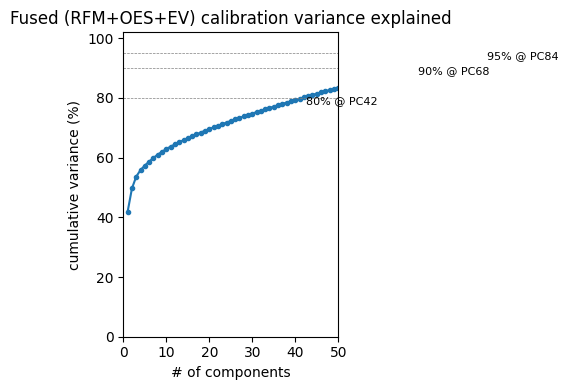

융합 PCA 주성분 수 A_f = 68 | PC1 단독: 41.9%


In [4]:
from sklearn.decomposition import PCA

pca_f_full = PCA().fit(Xc_fused)
cum_f = np.cumsum(pca_f_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,len(cum_f)+1), cum_f*100, 'o-', ms=3)
for thr in [80,90,95]:
    n = int(np.searchsorted(cum_f, thr/100)) + 1
    ax.axhline(thr, color='gray', ls='--', lw=.5)
    ax.text(n+0.5, thr-2, f"{thr}% @ PC{n}", fontsize=8)
ax.set_xlabel('# of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_xlim(0, 50); ax.set_ylim(0, 102)
ax.set_title('Fused (RFM+OES+EV) calibration variance explained')
plt.tight_layout(); plt.show()

A_f = int(np.searchsorted(cum_f, 0.90)) + 1
print(f"융합 PCA 주성분 수 A_f = {A_f} | PC1 단독: {pca_f_full.explained_variance_ratio_[0]*100:.1f}%")

=== 융합 MPCA (다중블록 PCA) ===
한계선: T²>100.22, Q>0.61
탐지 20/20 | 오탐 4/103

=== 스코어 OR 앙상블 (베이스라인) ===
탐지 20/20 | 오탐 10/103

=== 이상 웨이퍼별 탐지 비교 (Q_fused 큰 순) ===
         fault  T2_fused  Q_fused  hit_fused  hit_rfm  hit_oes  hit_ev
2917  RF +10    16226.28  7767.69       True     True     True    True
3120  TCP +30    7575.83  3655.59       True     True     True    True
3141  BCl3 -5     931.47   256.95       True     True     True    True
3122  RF +8       181.87    43.69       True     True     True    True
3318  TCP -15      78.16    23.22       True     True     True    True
2918  Pr +3       389.14    22.22       True     True     True    True
3142  Pr +2       332.90    18.62       True     True     True    True
3143  TCP -20      30.25     8.43       True     True     True    True
3341  TCP +20      31.62     7.48       True     True     True    True
2938  Pr -2        95.63     7.02       True    False     True    True
2915  TCP +50      32.83     3.07       True    False     True 

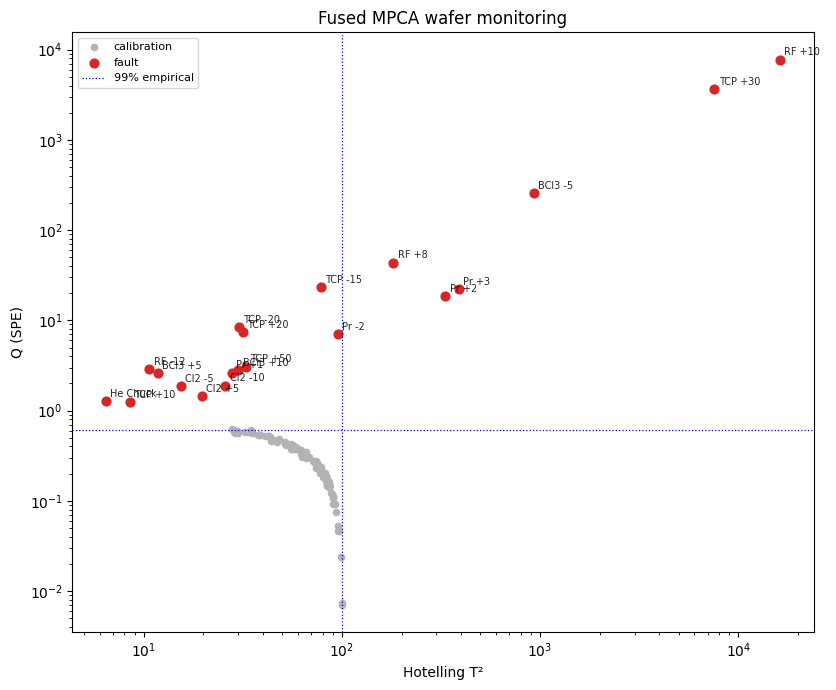

In [5]:
pca_f = PCA(n_components=A_f).fit(Xc_fused)
T_f   = pca_f.transform(X_fused)
res_f = X_fused - pca_f.inverse_transform(T_f)
T2_f  = (T_f**2 / pca_f.explained_variance_).sum(axis=1)
Q_f   = (res_f**2).sum(axis=1)

T2_lim_f = np.quantile(T2_f[~is_fault_all], 0.99)
Q_lim_f  = np.quantile(Q_f [~is_fault_all], 0.99)
hit_f    = (T2_f > T2_lim_f) | (Q_f > Q_lim_f)

ft_f = pd.DataFrame({
    'fault': label_all.values, 'T2_fused': T2_f.round(2), 'Q_fused': Q_f.round(2),
    'hit_fused': hit_f,
    'hit_rfm': R_S['hit_rfm'].values, 'hit_oes': O_S['hit_oes'].values, 'hit_ev': E_S['hit_ev'].values,
}, index=common)
ft_f_fault = ft_f[ft_f['fault']!='calibration'].sort_values('Q_fused', ascending=False)

# 블록별 OR 앙상블도 함께 계산
hit_OR = R_S['hit_rfm'].values | O_S['hit_oes'].values | E_S['hit_ev'].values

print(f"=== 융합 MPCA (다중블록 PCA) ===")
print(f"한계선: T²>{T2_lim_f:.2f}, Q>{Q_lim_f:.2f}")
print(f"탐지 {int(hit_f[is_fault_all].sum())}/{int(is_fault_all.sum())} | 오탐 {int(hit_f[~is_fault_all].sum())}/{int((~is_fault_all).sum())}")

print(f"\n=== 스코어 OR 앙상블 (베이스라인) ===")
print(f"탐지 {int(hit_OR[is_fault_all].sum())}/{int(is_fault_all.sum())} | 오탐 {int(hit_OR[~is_fault_all].sum())}/{int((~is_fault_all).sum())}")

print(f"\n=== 이상 웨이퍼별 탐지 비교 (Q_fused 큰 순) ===")
print(ft_f_fault[['fault','T2_fused','Q_fused','hit_fused','hit_rfm','hit_oes','hit_ev']].to_string())

# 산점도
fig, ax = plt.subplots(figsize=(8.5,7))
ax.scatter(T2_f[~is_fault_all], Q_f[~is_fault_all], s=20, c='0.7', label='calibration')
ax.scatter(T2_f[is_fault_all],  Q_f[is_fault_all],  s=40, c='#d62728', label='fault')
for i in np.where(is_fault_all)[0]:
    ax.annotate(label_all.iloc[i], (T2_f[i], Q_f[i]), fontsize=7,
                xytext=(3,3), textcoords='offset points', alpha=.85)
ax.axvline(T2_lim_f, color='b', ls=':', lw=.9, label='99% empirical')
ax.axhline(Q_lim_f,  color='b', ls=':', lw=.9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Hotelling T²'); ax.set_ylabel('Q (SPE)')
ax.set_title('Fused MPCA wafer monitoring')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
# 잔차 res_f를 블록 구간으로 나눠 각 블록의 Q 기여도 계산
nR, nO, nE = R_X.shape[1], O_X.shape[1], E_X.shape[1]
Q_R = (res_f[:, :nR]**2).sum(axis=1)
Q_O = (res_f[:, nR:nR+nO]**2).sum(axis=1)
Q_E = (res_f[:, nR+nO:]**2).sum(axis=1)
Q_total = Q_R + Q_O + Q_E

contrib = pd.DataFrame({
    'fault': label_all.values,
    'RFM%': (Q_R/Q_total*100).round(1),
    'OES%': (Q_O/Q_total*100).round(1),
    'EV%':  (Q_E/Q_total*100).round(1),
    'Q_total': Q_total.round(1),
}, index=common)
print("=== 각 이상 웨이퍼의 블록별 Q 기여도 (어디서 시그니처가 가장 강했나) ===")
print(contrib[contrib['fault']!='calibration'].sort_values('Q_total', ascending=False).to_string())

=== 각 이상 웨이퍼의 블록별 Q 기여도 (어디서 시그니처가 가장 강했나) ===
         fault  RFM%  OES%   EV%  Q_total
2917  RF +10    97.6   1.0   1.4   7767.7
3120  TCP +30   97.6   1.0   1.4   3655.6
3141  BCl3 -5    0.5   1.8  97.7    257.0
3122  RF +8      1.3   2.8  95.9     43.7
3318  TCP -15   88.0   4.5   7.4     23.2
2918  Pr +3      8.6  57.2  34.3     22.2
3142  Pr +2      6.7  65.3  28.0     18.6
3143  TCP -20   71.0   9.7  19.3      8.4
3341  TCP +20   71.4  11.3  17.3      7.5
2938  Pr -2      8.0  21.7  70.3      7.0
2915  TCP +50    7.3  34.7  58.0      3.1
3320  RF -12    54.2  19.5  26.3      2.9
3339  BCl3 +10  13.6  32.6  53.8      2.8
3340  Pr +1     16.8  38.1  45.1      2.6
2937  BCl3 +5   54.4  19.7  25.9      2.6
2939  Cl2 -5    33.4  28.2  38.4      1.9
3319  Cl2 -10   13.8  36.6  49.7      1.9
3121  Cl2 +5    12.7  37.9  49.4      1.4
2940  He Chuck   8.3  27.1  64.6      1.3
2936  TCP +10    9.6  43.5  46.9      1.2


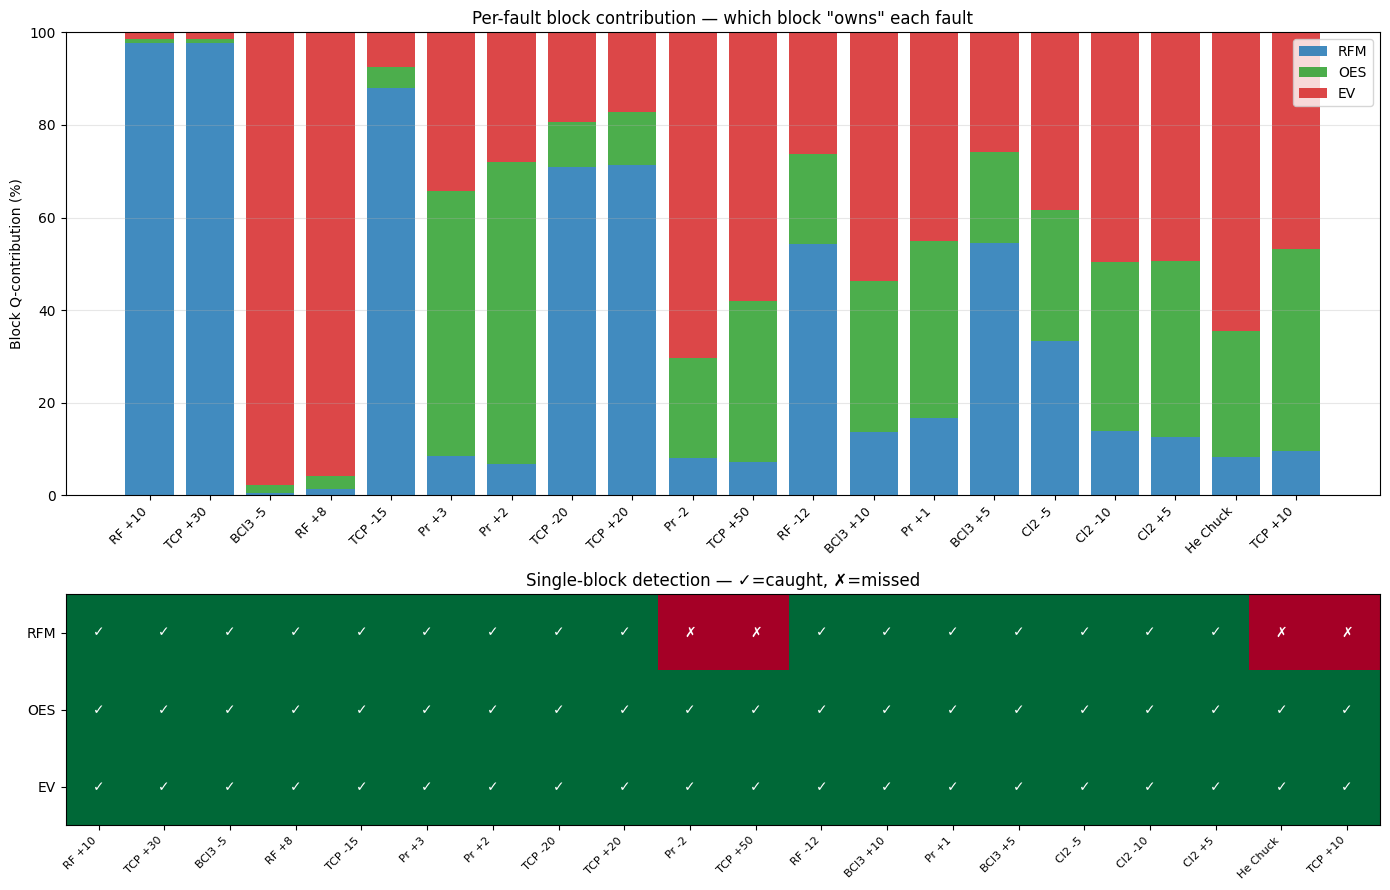

  에치 공정 이상탐지 시스템 — 최종 성능
  데이터: 123장 (정상 103, 이상 20)
  블록: RFM 1876dim + OES 4902dim + EV 1700dim = 8478dim
  ── 단일 블록 ──
     RFM:   16/20 탐지
     OES:   20/20 탐지
     EV:    20/20 탐지
  ── 융합 ──
     OR 앙상블:  20/20 탐지, 오탐 10/103
     다중블록 MPCA: 20/20 탐지, 오탐 4/103  ← 최종


In [7]:
ft_only = contrib[contrib['fault']!='calibration'].sort_values('Q_total', ascending=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios':[2,1]})

# 상단: 스택드 바 - 블록별 기여 %
x = np.arange(len(ft_only))
bottom = np.zeros(len(ft_only))
for col, color, name in [('RFM%','#1f77b4','RFM'), ('OES%','#2ca02c','OES'), ('EV%','#d62728','EV')]:
    ax1.bar(x, ft_only[col], bottom=bottom, label=name, color=color, alpha=.85)
    bottom += ft_only[col].values
ax1.set_xticks(x); ax1.set_xticklabels(ft_only['fault'].str.strip(), rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Block Q-contribution (%)'); ax1.set_ylim(0, 100)
ax1.set_title('Per-fault block contribution — which block "owns" each fault')
ax1.legend(loc='upper right'); ax1.grid(axis='y', alpha=.3)

# 하단: 블록별 단독 탐지 매트릭스
hit_matrix = pd.concat([
    R_S.loc[ft_only.index, 'hit_rfm'].rename('RFM'),
    O_S.loc[ft_only.index, 'hit_oes'].rename('OES'),
    E_S.loc[ft_only.index, 'hit_ev'].rename('EV'),
], axis=1).astype(int)

ax2.imshow(hit_matrix.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax2.set_yticks(range(3)); ax2.set_yticklabels(['RFM','OES','EV'])
ax2.set_xticks(x); ax2.set_xticklabels(ft_only['fault'].str.strip(), rotation=45, ha='right', fontsize=8)
ax2.set_title('Single-block detection — ✓=caught, ✗=missed')
for i in range(3):
    for j in range(len(ft_only)):
        ax2.text(j, i, '✓' if hit_matrix.iloc[j,i] else '✗',
                 ha='center', va='center', fontsize=10, color='white', weight='bold')

plt.tight_layout(); plt.show()

# 종합 요약 출력
print("="*60)
print("  에치 공정 이상탐지 시스템 — 최종 성능")
print("="*60)
print(f"  데이터: {len(common)}장 (정상 {(~is_fault_all).sum()}, 이상 {is_fault_all.sum()})")
print(f"  블록: RFM 1876dim + OES 4902dim + EV 1700dim = 8478dim")
print(f"  ── 단일 블록 ──")
print(f"     RFM:   {int(R_S.loc[ft_only.index, 'hit_rfm'].sum())}/{len(ft_only)} 탐지")
print(f"     OES:   {int(O_S.loc[ft_only.index, 'hit_oes'].sum())}/{len(ft_only)} 탐지")
print(f"     EV:    {int(E_S.loc[ft_only.index, 'hit_ev'].sum())}/{len(ft_only)} 탐지")
print(f"  ── 융합 ──")
print(f"     OR 앙상블:  {int(hit_OR[is_fault_all].sum())}/{is_fault_all.sum()} 탐지, 오탐 {int(hit_OR[~is_fault_all].sum())}/{(~is_fault_all).sum()}")
print(f"     다중블록 MPCA: {int(hit_f[is_fault_all].sum())}/{is_fault_all.sum()} 탐지, 오탐 {int(hit_f[~is_fault_all].sum())}/{(~is_fault_all).sum()}  ← 최종")
print("="*60)